<a href="https://colab.research.google.com/github/PrashVenga/AMLDM-CW-PART-1-FINAL-SUB-1-/blob/IBM-CW1-Part-1-Final-Sub-Codes/Copy_of_IBM_CW2_(Part_2)_Final(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Cost Regression Analysis (Part 2)

**Important Notice**

Before running this notebook, please ensure the dataset file  
`insurance.csv` is uploaded to your Google Drive under:

`MyDrive/insurance.csv`

Google Drive must be mounted before loading the dataset.  
If the file is stored in a different location, please update the file path accordingly in the dataset loading cell.

All results are generated after running the notebook sequentially from top to bottom.

# **Library Imports**

Required libraries for data processing, preprocessing pipelines, model development, and regression evaluation are imported.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# **Mount Google Drive and Define File Path**

Google Drive is mounted to access the Medical Cost dataset, and the file path to `insurance.csv` is specified.

In [14]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/insurance.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load and Inspect Dataset**

The Medical Cost dataset is loaded from the specified file path. The dataset shape and first few row

In [15]:
file_path = "/content/drive/MyDrive/insurance.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# **Data Overview and Quality Check**

Missing values, data types, and summary statistics are examined to assess data completeness and understand variable distributions before modelling.

In [16]:
print("Missing values per column:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics (numerical):")
display(df.describe())

print("\nSummary statistics (categorical):")
display(df.describe(include="object"))

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Summary statistics (numerical):


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Summary statistics (categorical):


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


# **Distribution of Target Variable**

The distribution of medical insurance charges is visualised to assess skewness and identify potent

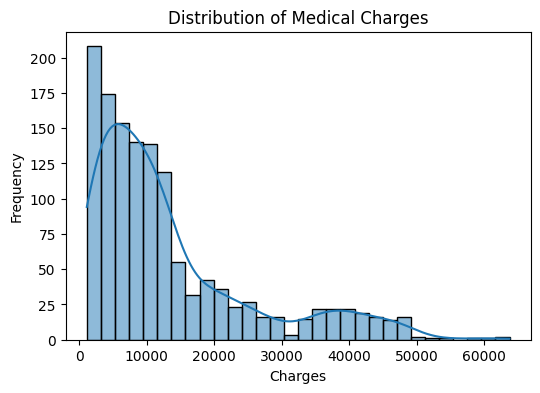

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

# **Define Predictors and Target**

The dataset is separated into predictor variables (X) and the continuous target variable (charges) for supervised regression modelling.

In [18]:
target = "charges"
X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 6)
y shape: (1338,)


# **Identify Feature Types**

Predictor variables are classified into categorical and numerical features to determine appropriate preprocessing steps.

In [19]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['sex', 'smoker', 'region']
Numerical columns: ['age', 'bmi', 'children']


# **Preprocessing Pipeline**

A ColumnTransformer is defined to apply One-Hot Encoding to categorical features while passing numerical features unchanged.

In [20]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols),
    ]
)

# **Train-Test Split**

The dataset is divided into training (70%) and testing (30%) sets to evaluate model performance on unseen data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (936, 6)
Test size : (402, 6)


# **Regression Evaluation Function**

A reusable evaluation function is defined to compute R², MAE, and RMSE for consistent assessment of regression model performance.

In [22]:
def evaluate_regression(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{model_name} Results")
    print("-" * 35)
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.2f}")
    print(f"RMSE     : {rmse:.2f}")

# **Linear Regression Model**

A baseline Linear Regression model is implemented within a preprocessing pipeline, trained on the training set, and evaluated on the test data.

In [23]:
linreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

linreg_pipeline.fit(X_train, y_train)

linreg_pred = linreg_pipeline.predict(X_test)
evaluate_regression("Linear Regression (Baseline)", y_test, linreg_pred)


Linear Regression (Baseline) Results
-----------------------------------
R² Score : 0.7696
MAE      : 4145.45
RMSE     : 5812.10


# **Cross-Validation (Linear Regression)**

Five-fold cross-validation is performed to evaluate the stability and generalisation performance of the Linear Regression model.

In [24]:
linreg_cv = cross_val_score(linreg_pipeline, X, y, cv=5, scoring="r2")

print("\nLinear Regression Cross-Validation (5-fold)")
print("-" * 45)
print(f"Mean R²: {linreg_cv.mean():.4f}")
print(f"Std R² : {linreg_cv.std():.4f}")


Linear Regression Cross-Validation (5-fold)
---------------------------------------------
Mean R²: 0.7469
Std R² : 0.0249


# **Random Forest Regressor**

A Random Forest model is implemented within a preprocessing pipeline to capture non-linear relationships and improve predictive performance.

In [25]:
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
evaluate_regression("Random Forest Regressor", y_test, rf_pred)


Random Forest Regressor Results
-----------------------------------
R² Score : 0.8541
MAE      : 2556.37
RMSE     : 4624.87


# **Cross-Validation (Random Forest)**

Five-fold cross-validation is conducted to assess the consistency and generalisation performance of the Random Forest model.

In [26]:
rf_cv = cross_val_score(rf_pipeline, X, y, cv=5, scoring="r2")

print("\nRandom Forest Cross-Validation (5-fold)")
print("-" * 45)
print(f"Mean R²: {rf_cv.mean():.4f}")
print(f"Std R² : {rf_cv.std():.4f}")


Random Forest Cross-Validation (5-fold)
---------------------------------------------
Mean R²: 0.8385
Std R² : 0.0333


# **Feature Importance Analysis (Random Forest)**

Feature importance scores are extracted from the trained Random Forest model to identify the most influential predictors of medical insurance charges.

In [27]:
# Get transformed feature names from OneHotEncoder
ohe = rf_pipeline.named_steps["preprocess"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([ohe_feature_names, numerical_cols])

importances = rf_pipeline.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 15 Feature Importances (Random Forest):")
display(feat_imp.head(15))


Top 15 Feature Importances (Random Forest):


,feature,importance
2,smoker_no,0.410289
9,bmi,0.205992
3,smoker_yes,0.197028
8,age,0.139468
10,children,0.020646
4,region_northeast,0.006213
5,region_northwest,0.004500
1,sex_male,0.004365
6,region_southeast,0.004012
0,sex_female,0.003987
